In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Ready for Project 5!")

Ready for Project 5!


In [2]:
np.random.seed(42)
n = 1000

categories = ['Art & Design', 'Business', 'Comics', 'Communication',
              'Education', 'Entertainment', 'Finance', 'Food & Drink',
              'Health & Fitness', 'Music', 'Photography', 'Productivity',
              'Shopping', 'Social', 'Tools']

apps = pd.DataFrame({
    'App': [f'App_{i}' for i in range(1, n+1)],
    'Category': np.random.choice(categories, n),
    'Rating': np.random.uniform(1.0, 5.0, n).round(1),
    'Reviews': np.random.randint(100, 1000000, n),
    'Size_MB': np.random.uniform(1.0, 100.0, n).round(1),
    'Installs': np.random.choice([
        '1,000+', '10,000+', '50,000+',
        '100,000+', '500,000+', '1,000,000+',
        '5,000,000+', '10,000,000+'
    ], n),
    'Type': np.random.choice(['Free', 'Paid'], n, p=[0.85, 0.15]),
    'Price': 0.0,
    'Content_Rating': np.random.choice([
        'Everyone', 'Teen', 'Mature 17+'], n),
    'Genres': np.random.choice(categories, n),
    'Sentiment': np.random.choice([
        'Positive', 'Negative', 'Neutral'], n),
})

# Set price for paid apps
paid_mask = apps['Type'] == 'Paid'
apps.loc[paid_mask, 'Price'] = np.random.uniform(0.99, 9.99,
                                paid_mask.sum()).round(2)

# Add some missing values
apps.loc[np.random.choice(n, 30), 'Rating'] = np.nan
apps.loc[np.random.choice(n, 20), 'Size_MB'] = np.nan

apps.to_csv('playstore_data.csv', index=False)
print("Dataset created!")
print("Shape:", apps.shape)
print(apps.head())

Dataset created!
Shape: (1000, 11)
     App       Category  Rating  Reviews  Size_MB    Installs  Type  Price  \
0  App_1        Finance     2.0    63746     51.7  1,000,000+  Free    0.0   
1  App_2  Communication     2.1   265898     80.8    100,000+  Free    0.0   
2  App_3       Shopping     1.8   482338     46.5    100,000+  Free    0.0   
3  App_4          Tools     4.5   805275      6.1     50,000+  Free    0.0   
4  App_5    Photography     4.0   834900     78.8    100,000+  Free    0.0   

  Content_Rating        Genres Sentiment  
0     Mature 17+  Art & Design  Positive  
1       Everyone   Photography  Negative  
2     Mature 17+   Photography  Positive  
3     Mature 17+  Food & Drink   Neutral  
4           Teen        Comics  Negative  


In [3]:
df = pd.read_csv('playstore_data.csv')
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Shape: (1000, 11)

Missing Values:
App                0
Category           0
Rating            30
Reviews            0
Size_MB           20
Installs           0
Type               0
Price              0
Content_Rating     0
Genres             0
Sentiment          0
dtype: int64

Data Types:
App                   str
Category              str
Rating            float64
Reviews             int64
Size_MB           float64
Installs              str
Type                  str
Price             float64
Content_Rating        str
Genres                str
Sentiment             str
dtype: object


In [4]:
# Fix missing values
df['Rating'].fillna(df['Rating'].median(), inplace=True)
df['Size_MB'].fillna(df['Size_MB'].median(), inplace=True)

# Fix installs column
df['Installs_Clean'] = df['Installs'].str.replace(
    '[+,]', '', regex=True).astype(int)

print("Data cleaned!")
print("Missing values:", df.isnull().sum().sum())
print(df.head())

Data cleaned!
Missing values: 50
     App       Category  Rating  Reviews  Size_MB    Installs  Type  Price  \
0  App_1        Finance     2.0    63746     51.7  1,000,000+  Free    0.0   
1  App_2  Communication     2.1   265898     80.8    100,000+  Free    0.0   
2  App_3       Shopping     1.8   482338     46.5    100,000+  Free    0.0   
3  App_4          Tools     4.5   805275      6.1     50,000+  Free    0.0   
4  App_5    Photography     4.0   834900     78.8    100,000+  Free    0.0   

  Content_Rating        Genres Sentiment  Installs_Clean  
0     Mature 17+  Art & Design  Positive         1000000  
1       Everyone   Photography  Negative          100000  
2     Mature 17+   Photography  Positive          100000  
3     Mature 17+  Food & Drink   Neutral           50000  
4           Teen        Comics  Negative          100000  


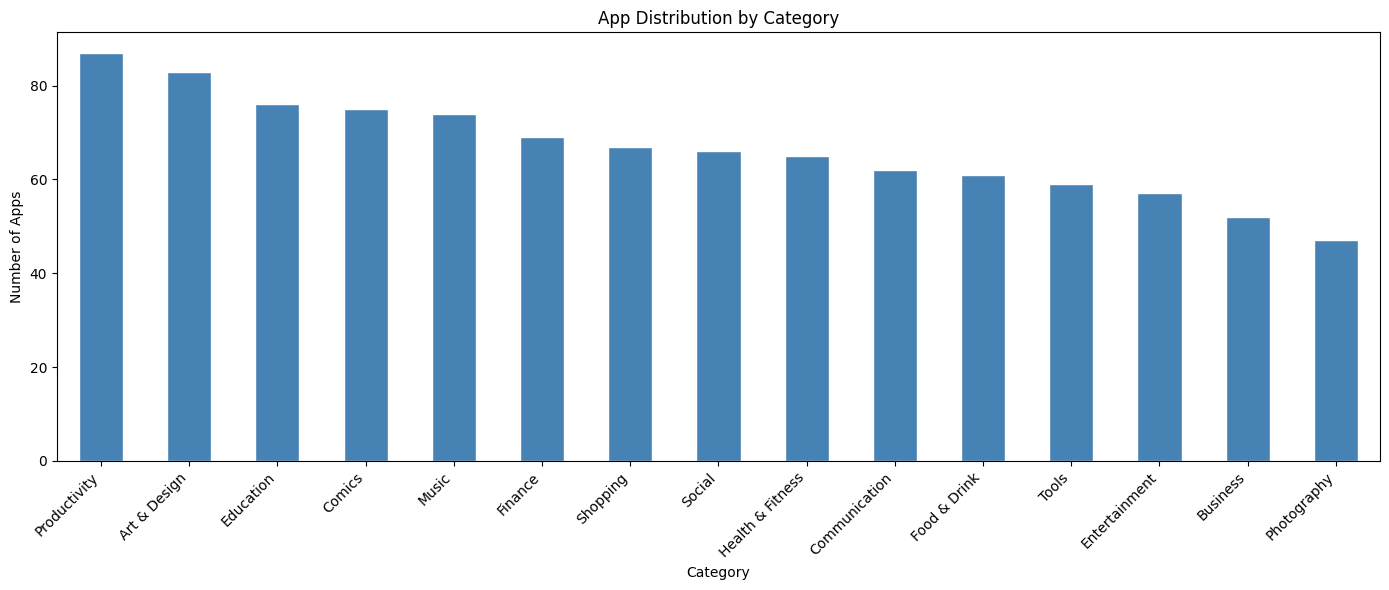

Chart saved!


In [5]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(14, 6))
category_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('App Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_dist.png')
plt.show()
print("Chart saved!")

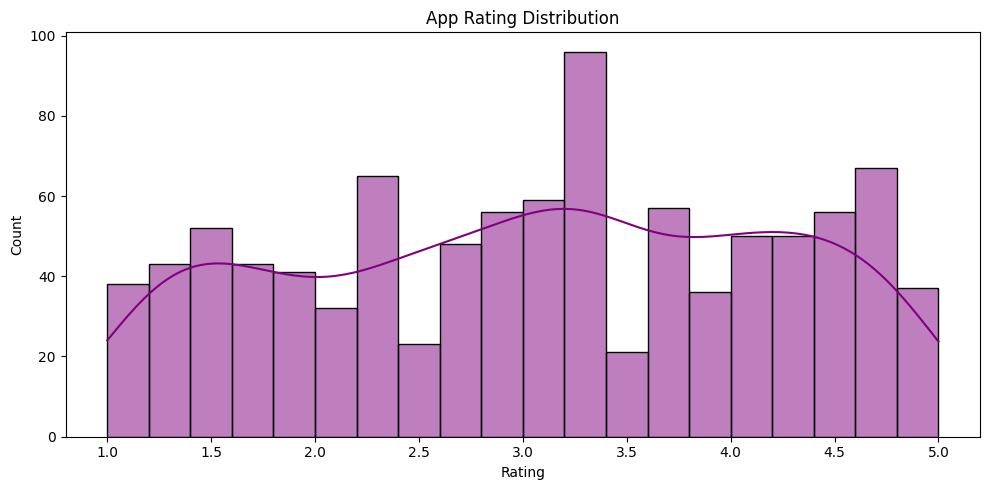

Chart saved!


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='purple')
plt.title('App Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rating_dist.png')
plt.show()
print("Chart saved!")

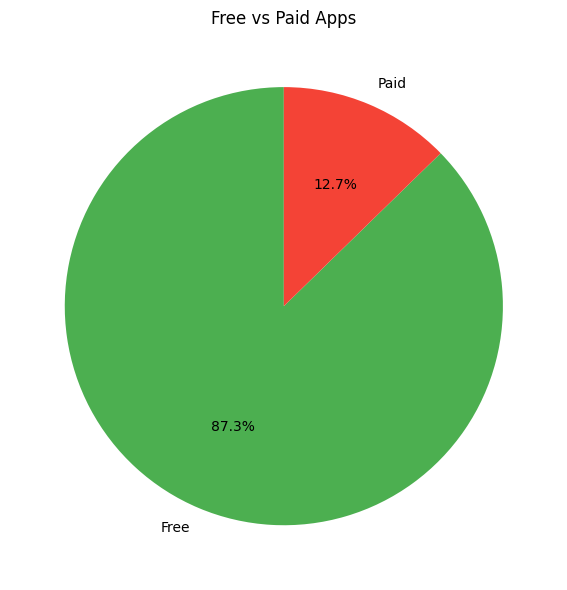

Chart saved!


In [7]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index,
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90)
plt.title('Free vs Paid Apps')
plt.tight_layout()
plt.savefig('free_vs_paid.png')
plt.show()
print("Chart saved!")

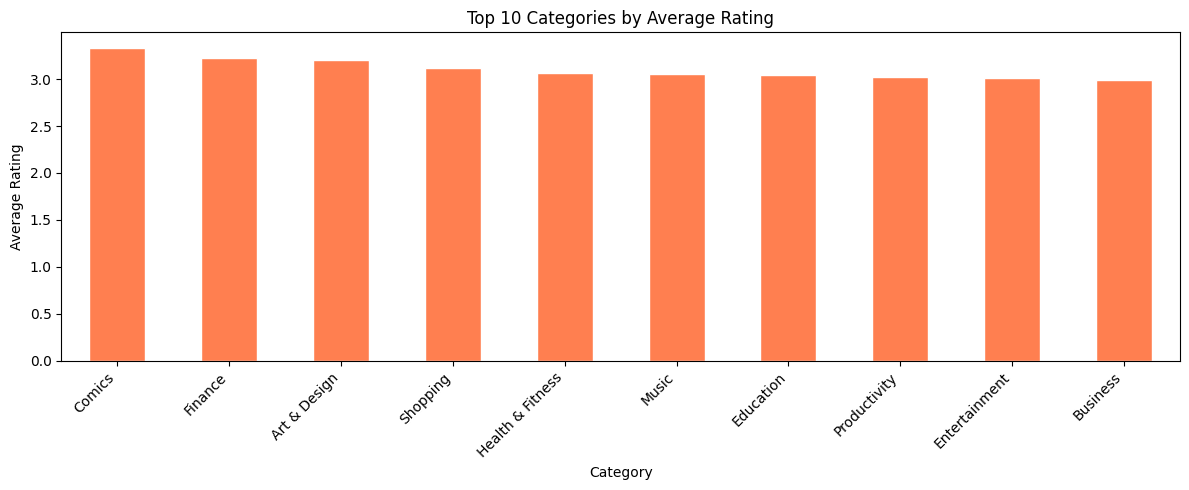

Chart saved!


In [8]:
top_rated = df.groupby('Category')['Rating'].mean().sort_values(
    ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_rated.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_rated.png')
plt.show()
print("Chart saved!")

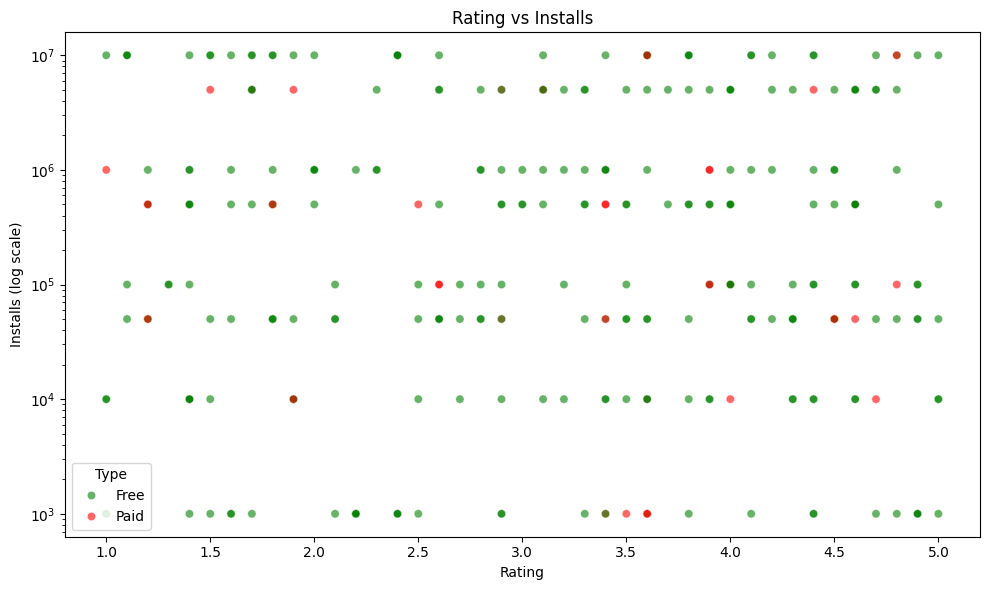

Chart saved!


In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(300),
                x='Rating',
                y='Installs_Clean',
                hue='Type',
                alpha=0.6,
                palette=['green', 'red'])
plt.yscale('log')
plt.title('Rating vs Installs')
plt.xlabel('Rating')
plt.ylabel('Installs (log scale)')
plt.tight_layout()
plt.savefig('rating_vs_installs.png')
plt.show()
print("Chart saved!")

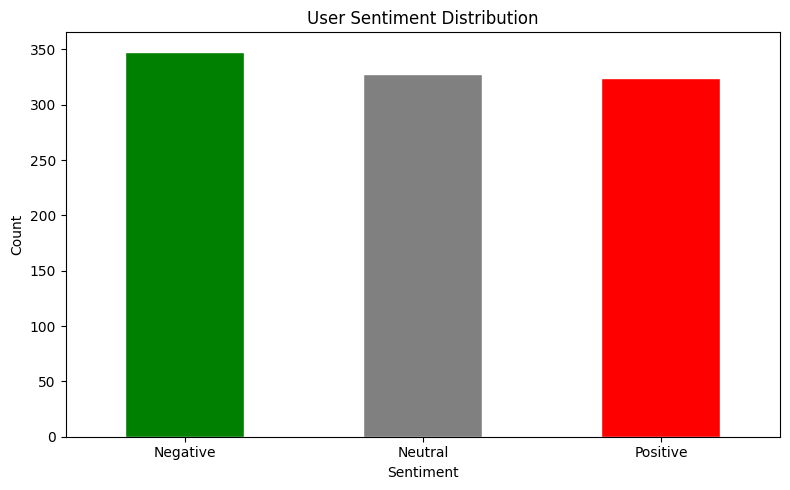

Chart saved!


In [10]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar',
                      color=['green', 'gray', 'red'],
                      edgecolor='white')
plt.title('User Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment.png')
plt.show()
print("Chart saved!")

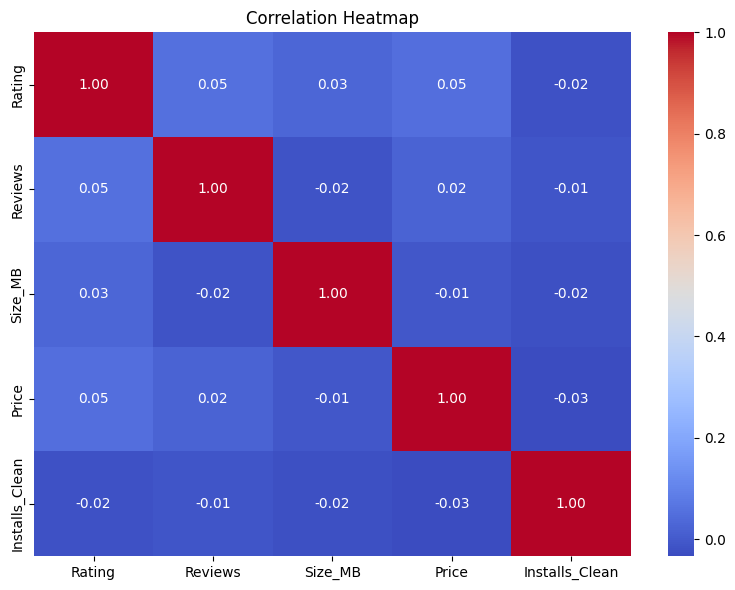

Chart saved!


In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Rating', 'Reviews', 'Size_MB',
                'Price', 'Installs_Clean']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
print("Chart saved!")

In [12]:
print("========== PROJECT 5 SUMMARY ==========")
print(f"Total Apps        : {len(df)}")
print(f"Total Categories  : {df['Category'].nunique()}")
print(f"Average Rating    : {df['Rating'].mean():.2f}")
print(f"Free Apps         : {len(df[df['Type']=='Free'])}")
print(f"Paid Apps         : {len(df[df['Type']=='Paid'])}")
print(f"Most Apps In      : {df['Category'].value_counts().index[0]}")
print(f"Top Rated Category: {top_rated.index[0]}")
print()
print("Charts saved:")
print("✅ Category Distribution")
print("✅ Rating Distribution")
print("✅ Free vs Paid")
print("✅ Top Rated Categories")
print("✅ Rating vs Installs")
print("✅ Sentiment Distribution")
print("✅ Correlation Heatmap")
print("========================================")
print("Project 5 Complete!")

========== PROJECT 5 SUMMARY ==========
Total Apps        : 1000
Total Categories  : 15
Average Rating    : 3.05
Free Apps         : 873
Paid Apps         : 127
Most Apps In      : Productivity
Top Rated Category: Comics

Charts saved:
✅ Category Distribution
✅ Rating Distribution
✅ Free vs Paid
✅ Top Rated Categories
✅ Rating vs Installs
✅ Sentiment Distribution
✅ Correlation Heatmap
Project 5 Complete!
